# Simulação de Epidemias  
Disciplina: Ciência de Redes


### Integrantes
- Anderson Falcão
- Leonardo Alexandre  
- Ramyro Corrêa

---

#### Objetivo do Notebook

Este notebook contém a implementaçãoo das simulações do modelo **SIS (Suscetível-Infectado-Suscetível)** aplicado em dois tipos de redes:

- Rede aleatória
- Redes livre de escala

Ao longo do notebook, serão realizadas:

1. **Geração das redes** com 10.000 vértices e grau médio ≥ 20.  
2. **Simulações do processo epidêmico** para diferentes valores de β e μ.  
3. **Comparações entre simulações e resultados esperados pela teoria de campo médio.**  
4. **Estudo do limiar epidêmico: \( R_0 = \frac{\beta \langle k \rangle}{\mu} \).**  
5. **Experimentos de imunização** (aleatória, hubs e vizinhos) e análise da robustez da rede.

In [ ]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

#### 1. Simulação do Modelo SIS em Rede Aleatória (ER)

Gere uma rede aleatória (ER) com 10000 vértices e grau médio < 𝑘 >= 20. Comece
com 5 vértices infectados escolhidos aleatoriamente. Execute múltiplas simulações da
propagação da infecção pelo modelo SIS com os parâmetros abaixo e compare com os
resultados esperados. (sugestão: faça em torno de 100 simulações e descreva o
comportamento da epidemia “na média”)

**a.** β = 0.02 e μ = 0.1  
**b.** β = 0.02 e μ = 0.4  
**c.** β = 0.02 e μ = 0.5  

Mostre que $R_0 = \frac{\beta \langle k \rangle}{\mu} > 1$, então a doença tende a se fixar (estado endêmico) no modelo de campo médio.

In [4]:
def simulate_sis(G, beta, mu, initial_infected=5, steps=200):
    nodes = list(G.nodes())
    
    # Estado inicial
    infected = set(random.sample(nodes, initial_infected))
    infected_history = []

    for t in range(steps):
        new_infected = set(infected)

        # infecta
        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected and random.random() < beta:
                    new_infected.add(neighbor)

        # recupera
        for node in list(new_infected):
            if random.random() < mu:
                new_infected.remove(node)

        infected = new_infected
        infected_history.append(len(infected) / len(nodes))

    return infected_history

In [5]:
def run_experiments(G, beta, mu, runs=100, steps=200):
    all_runs = []

    for _ in tqdm(range(runs), desc=f"β={beta}, μ={mu}"):
        hist = simulate_sis(G, beta, mu, steps=steps)
        all_runs.append(hist)

    mean_curve = np.mean(all_runs, axis=0)
    return mean_curve

In [6]:
N = 10000
k = 20
p = k / (N - 1)

G = nx.erdos_renyi_graph(N, p)
print("Rede ER gerada.")

Rede ER gerada.


In [11]:
params = [
    (0.02, 0.1),
    (0.02, 0.4),
    (0.02, 0.5)
]

results = {}

for beta, mu in params:
    mean_curve = run_experiments(G, beta, mu, runs=100, steps=200)
    results[(beta, mu)] = mean_curve

β=0.02, μ=0.5: 100%|██████████| 100/100 [00:00<00:00, 5889.06it/s]


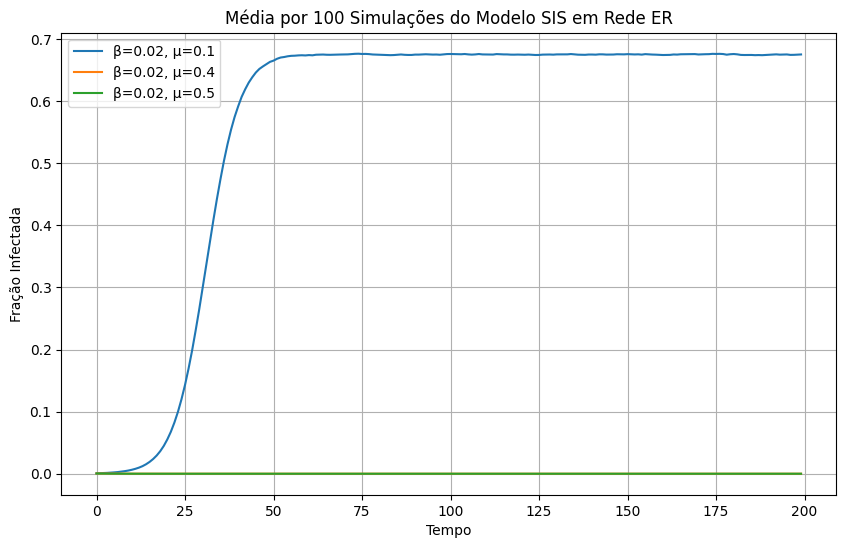

In [15]:
plt.figure(figsize=(10,6))

for (beta, mu), curve in results.items():
    plt.plot(curve, label=f"β={beta}, μ={mu}")

plt.xlabel("Tempo")
plt.ylabel("Fração Infectada")
plt.title("Média por 100 Simulações do Modelo SIS em Rede ER")
plt.legend()
plt.grid(True)
plt.show()